# Exemplo 2 — RK de Quarta Ordem

**Slide p. 23** — Integrar numericamente

$$\frac{dy}{dx} = -2x^3 + 12x^2 - 20x + 8{,}5$$

de $x = 0$ a $x = 5$ com $h = 0{,}1$ e $y(0) = 1$.

y(5.0) = -19.000000   exato = -19.000000
Erro máximo = 1.137e-13


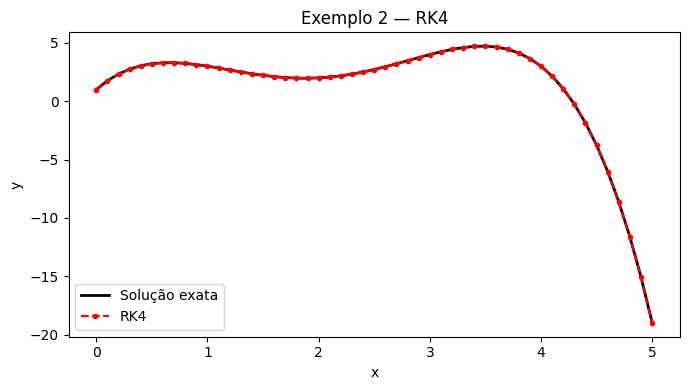

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2*x**3 + 12*x**2 - 20*x + 8.5

def y_exato(x):
    return -0.5*x**4 + 4*x**3 - 10*x**2 + 8.5*x + 1

x0, y0, h = 0.0, 1.0, 0.1
x_end = 5.0

x, y = x0, y0
xs, ys = [x], [y]

while x < x_end - 1e-10:
    k1 = f(x,       y)
    k2 = f(x + h/2, y + k1 * h/2)
    k3 = f(x + h/2, y + k2 * h/2)
    k4 = f(x + h,   y + k3 * h)
    y = y + (k1 + 2*k2 + 2*k3 + k4) * h / 6
    x = x + h
    xs.append(x)
    ys.append(y)

xs = np.array(xs)
ys = np.array(ys)

print(f"y(5.0) = {ys[-1]:.6f}   exato = {y_exato(5.0):.6f}")
print(f"Erro máximo = {np.max(np.abs(ys - y_exato(xs))):.3e}")

plt.figure(figsize=(7, 4))
plt.plot(xs, y_exato(xs), 'k-', lw=2, label='Solução exata')
plt.plot(xs, ys, 'r--o', ms=3, label='RK4')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Exemplo 2 — RK4')
plt.legend(); plt.tight_layout(); plt.show()
